In [2]:
import pandas as pd
import pyodbc

server = r"LAPTOP-P3LI1TMH\SQLEXPRESS"
database = "ecommerce_analytics"

conn = pyodbc.connect(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

print("Connected to SQL Server successfully!")

Connected to SQL Server successfully!


In [3]:
import sys
import pandas as pd
import pyodbc
import matplotlib.pyplot as plt
import numpy as np
print(sys.executable)
print("Pandas:", pd.__version__)
print("ODBC drivers:", pyodbc.drivers())

c:\Users\pc\AppData\Local\Programs\Python\Python312\python.exe
Pandas: 2.1.4
ODBC drivers: ['SQL Server', 'SQL Server Native Client RDA 11.0', 'ODBC Driver 17 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']


# E-commerce Exploratory Data Analysis

## 1. Load Analytical Dataset

This notebook uses cleaned data from SQL Server to explore sales,
customers, products, and purchasing patterns.

Only delivered orders are included in the main sales analysis.

In [4]:
query = """
SELECT
    o.order_id,
    c.customer_unique_id,
    o.order_purchase_timestamp,
    c.customer_state,

    oi.product_id,
    p.category_name,

    oi.price,
    oi.freight_value

FROM dbo.orders AS o

INNER JOIN dbo.customers AS c
    ON o.customer_id = c.customer_id

INNER JOIN dbo.vw_order_items_clean AS oi
    ON o.order_id = oi.order_id

LEFT JOIN dbo.vw_products_clean AS p
    ON oi.product_id = p.product_id

WHERE o.order_status = 'delivered';
"""

sales_df = pd.read_sql(query, conn)

print("Dataset shape:", sales_df.shape)

sales_df.head()

C:\Users\pc\AppData\Local\Temp\ipykernel_1536\2345744431.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df = pd.read_sql(query, conn)


Dataset shape: (110197, 8)


,order_id,customer_unique_id,order_purchase_timestamp,customer_state,product_id,category_name,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,2017-09-13 08:59:02,RJ,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,2017-04-26 10:53:06,SP,e5f2d52b802189ee658865ca93d83a8f,pet_shop,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,2018-01-14 14:33:31,MG,c777355d18b72b67abbeef9df44fd0fd,furniture_decor,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,2018-08-08 10:00:35,SP,7634da152a4610f1595efa32f14722fc,perfumery,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,2017-02-04 13:57:51,SP,ac6c3623068f30de03045865e4e10089,garden_tools,199.90,18.14


In [5]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  110197 non-null  object        
 1   customer_unique_id        110197 non-null  object        
 2   order_purchase_timestamp  110197 non-null  datetime64[ns]
 3   customer_state            110197 non-null  object        
 4   product_id                110197 non-null  object        
 5   category_name             110197 non-null  object        
 6   price                     110197 non-null  float64       
 7   freight_value             110197 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 6.7+ MB


In [6]:
sales_df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,110197,96478,8272b63d03f5f79c56e9e4120aec44ef,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,110197,93358,c8460e4251689ba205045f3ea17884a1,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,110197,NaN,NaN,NaN,2018-01-02 02:49:51.928346368,2016-09-15 12:16:38,2017-09-15 06:32:42,2018-01-21 10:11:55,2018-05-05 16:03:59,2018-08-29 15:00:37,NaN
customer_state,110197,27,SP,46448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,110197,32216,aca2eb7d00ea1a7b8ebd4e68314663af,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_name,110197,74,bed_bath_table,10953,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,110197.0,NaN,NaN,NaN,119.980563,0.85,39.9,74.9,134.17,6735.0,182.299446
freight_value,110197.0,NaN,NaN,NaN,19.948598,0.0,13.08,16.26,21.15,409.68,15.698136


In [7]:
print("Rows / units sold:", len(sales_df))
print("Unique orders:", sales_df["order_id"].nunique())
print("Unique customers:", sales_df["customer_unique_id"].nunique())
print("Unique products:", sales_df["product_id"].nunique())
print("Total revenue:", round(sales_df["price"].sum(), 2))

Rows / units sold: 110197
Unique orders: 96478
Unique customers: 93358
Unique products: 32216
Total revenue: 13221498.11


## 2. Data Validation

The analytical dataset is validated against the SQL results to ensure
that the SQL-to-Python pipeline preserves the expected number of orders,
customers, products, and total revenue.

In [8]:
# Validate the analytical dataset

print("Dataset shape:", sales_df.shape)
print("Rows / units sold:", len(sales_df))
print("Unique orders:", sales_df["order_id"].nunique())
print("Unique customers:", sales_df["customer_unique_id"].nunique())
print("Unique products:", sales_df["product_id"].nunique())
print("Total revenue:", round(sales_df["price"].sum(), 2))

print("\nMissing values:")
print(sales_df.isnull().sum())

print("\nData types:")
print(sales_df.dtypes)

Dataset shape: (110197, 8)
Rows / units sold: 110197
Unique orders: 96478
Unique customers: 93358
Unique products: 32216
Total revenue: 13221498.11

Missing values:
order_id                    0
customer_unique_id          0
order_purchase_timestamp    0
customer_state              0
product_id                  0
category_name               0
price                       0
freight_value               0
dtype: int64

Data types:
order_id                            object
customer_unique_id                  object
order_purchase_timestamp    datetime64[ns]
customer_state                      object
product_id                          object
category_name                       object
price                              float64
freight_value                      float64
dtype: object


## 3. Feature Engineering

Time-based features are created from the order purchase timestamp
to support monthly and weekly sales analysis.

In [9]:
# Convert timestamp and create time-based features

sales_df["order_purchase_timestamp"] = pd.to_datetime(
    sales_df["order_purchase_timestamp"]
)

sales_df["order_year"] = sales_df["order_purchase_timestamp"].dt.year

sales_df["order_month"] = (
    sales_df["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

sales_df["order_day_of_week"] = (
    sales_df["order_purchase_timestamp"]
    .dt.day_name()
)

sales_df[
    [
        "order_purchase_timestamp",
        "order_year",
        "order_month",
        "order_day_of_week"
    ]
].head()

,order_purchase_timestamp,order_year,order_month,order_day_of_week
0,2017-09-13 08:59:02,2017,2017-09-01,Wednesday
1,2017-04-26 10:53:06,2017,2017-04-01,Wednesday
2,2018-01-14 14:33:31,2018,2018-01-01,Sunday
3,2018-08-08 10:00:35,2018,2018-08-01,Wednesday
4,2017-02-04 13:57:51,2017,2017-02-01,Saturday


## 4. Sales Trend Analysis

### Monthly Revenue and Order Volume

This section examines how delivered-order revenue and order volume
changed over time.

In [10]:
monthly_sales = (
    sales_df
    .groupby("order_month")
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_sales["aov"] = (
    monthly_sales["revenue"] / monthly_sales["orders"]
)

monthly_sales.head()

,order_month,revenue,orders,aov
0,2016-09-01,134.97,1,134.970000
1,2016-10-01,40325.11,265,152.170226
2,2016-12-01,10.90,1,10.900000
3,2017-01-01,111798.36,750,149.064480
4,2017-02-01,234223.40,1653,141.695947


In [11]:
monthly_sales.sort_values(
    "revenue",
    ascending=False
).head(5)

,order_month,revenue,orders,aov
13,2017-11-01,987765.37,7289,135.514525
19,2018-05-01,977544.69,6749,144.842894
18,2018-04-01,973534.09,6798,143.208898
17,2018-03-01,953356.25,7003,136.135406
15,2018-01-01,924645.00,7069,130.802801


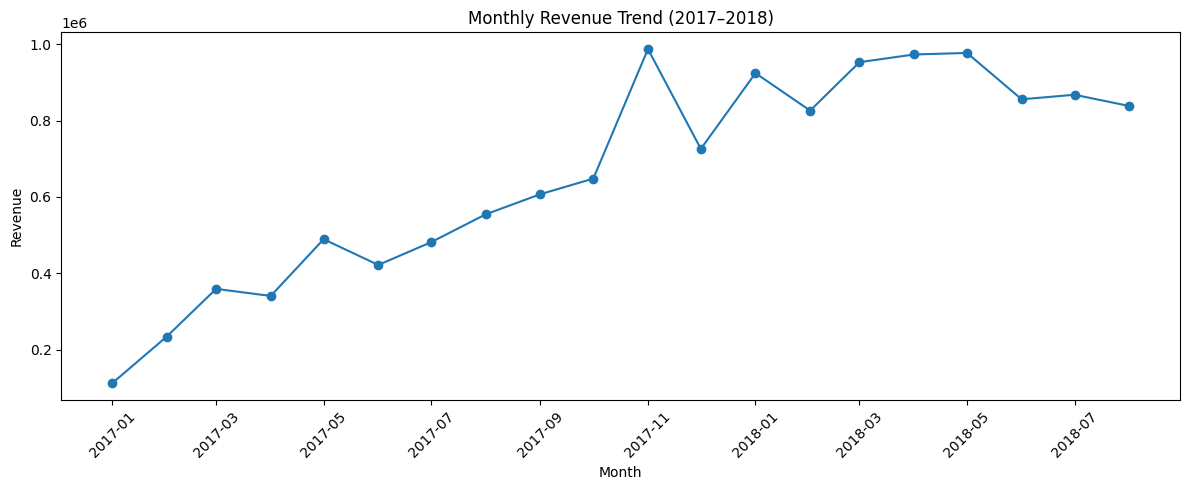

In [12]:
# Focus on the stable analysis period from January 2017 onward

monthly_sales_stable = monthly_sales[
    monthly_sales["order_month"] >= "2017-01-01"
].copy()

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales_stable["order_month"],
    monthly_sales_stable["revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend (2017–2018)")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Finding

Revenue generally increased throughout 2017 and reached its highest level
in November 2017 at approximately 987.8K.

The November spike was mainly driven by higher order volume rather than a
substantial increase in average order value.

Revenue remained relatively high during 2018, although the dataset only
covers part of the year.

### Order Volume and Average Order Value

To better understand the drivers of revenue growth, monthly order volume
and average order value are analyzed separately.

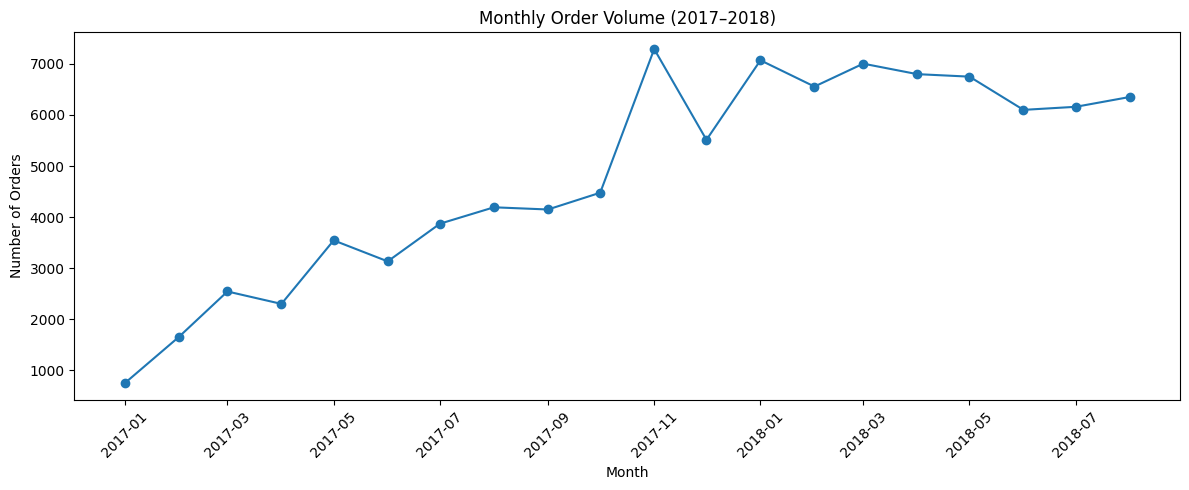

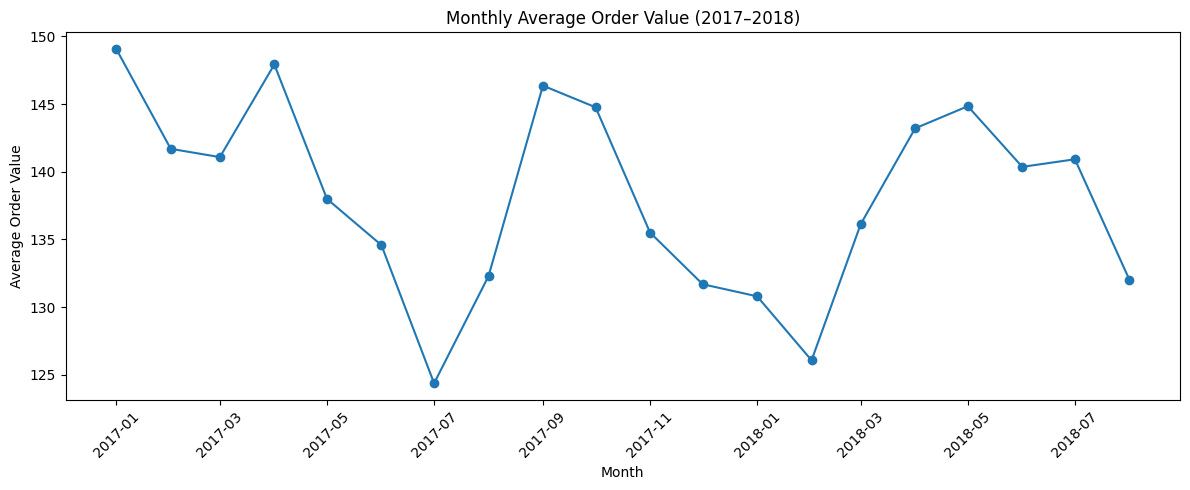

In [13]:
# Analyze monthly order volume and average order value

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales_stable["order_month"],
    monthly_sales_stable["orders"],
    marker="o"
)

plt.title("Monthly Order Volume (2017–2018)")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales_stable["order_month"],
    monthly_sales_stable["aov"],
    marker="o"
)

plt.title("Monthly Average Order Value (2017–2018)")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Finding

Monthly order volume increased substantially during the analysis period
and closely followed the overall revenue trend.

November 2017 recorded the highest order volume, while average order value
was approximately 135.51. Although AOV fluctuated across months, it did not
show the same sustained growth pattern as order volume.

This suggests that revenue growth was driven primarily by increasing
transaction volume rather than a persistent increase in spending per order.

## 5. Customer Analysis

### One-Time vs Repeat Customers

This section examines customer purchase frequency to understand how much
of the customer base consists of one-time buyers versus repeat customers.

In [14]:
# Build customer-level purchase summary

customer_summary = (
    sales_df
    .groupby("customer_unique_id")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("price", "sum")
    )
    .reset_index()
)

customer_summary["customer_type"] = np.where(
    customer_summary["orders"] == 1,
    "One-Time",
    "Repeat"
)

customer_type_summary = (
    customer_summary
    .groupby("customer_type")
    .agg(
        customers=("customer_unique_id", "count"),
        revenue=("revenue", "sum")
    )
    .reset_index()
)

customer_type_summary["customer_share_pct"] = (
    100
    * customer_type_summary["customers"]
    / customer_type_summary["customers"].sum()
)

customer_type_summary["revenue_share_pct"] = (
    100
    * customer_type_summary["revenue"]
    / customer_type_summary["revenue"].sum()
)

customer_type_summary

,customer_type,customers,revenue,customer_share_pct,revenue_share_pct
0,One-Time,90557,12493089.36,96.999722,94.490725
1,Repeat,2801,728408.75,3.000278,5.509275


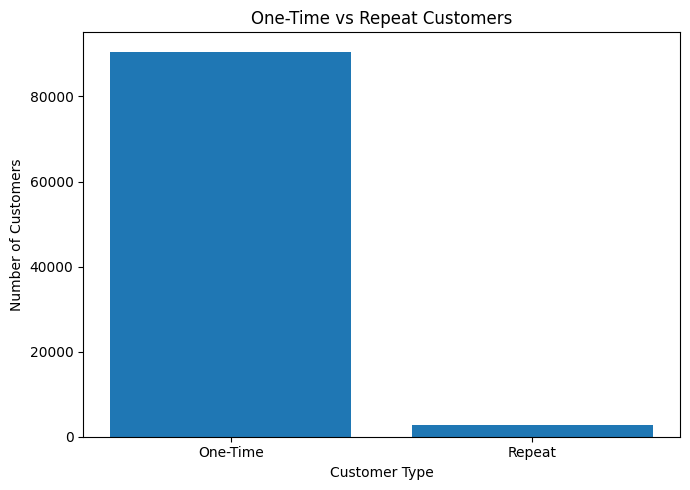

In [15]:
plt.figure(figsize=(7, 5))

plt.bar(
    customer_type_summary["customer_type"],
    customer_type_summary["customers"]
)

plt.title("One-Time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Finding

The customer base is heavily dominated by one-time buyers.

Approximately 97% of customers placed only one delivered order, while
repeat customers represent about 3% of the customer base.

Despite their small share, repeat customers generate substantially more
revenue per customer than one-time buyers. This makes repeat purchasing
an important area for further retention analysis.

## 6. Product and Category Analysis

### Category Performance

This section compares product categories based on revenue and sales volume
to identify differences between value-driven and volume-driven categories.

In [16]:
# Aggregate product category performance

category_summary = (
    sales_df
    .groupby("category_name")
    .agg(
        units_sold=("product_id", "count"),
        orders=("order_id", "nunique"),
        revenue=("price", "sum"),
        avg_item_price=("price", "mean")
    )
    .reset_index()
)

category_summary = category_summary.sort_values(
    "revenue",
    ascending=False
)

category_summary.head(10)

,category_name,units_sold,orders,revenue,avg_item_price
44,health_beauty,9465,8647,1233131.72,130.283330
73,watches_gifts,5859,5495,1166176.98,199.040276
8,bed_bath_table,10953,9272,1023434.76,93.438762
68,sports_leisure,8431,7530,954852.55,113.254958
16,computers_accessories,7644,6530,888724.61,116.264339
40,furniture_decor,8160,6307,711927.69,87.246040
50,housewares,6795,5743,615628.69,90.600249
21,cool_stuff,3718,3559,610204.10,164.121598
6,auto,4140,3810,578966.65,139.847017
72,toys,4030,3804,471286.48,116.944536


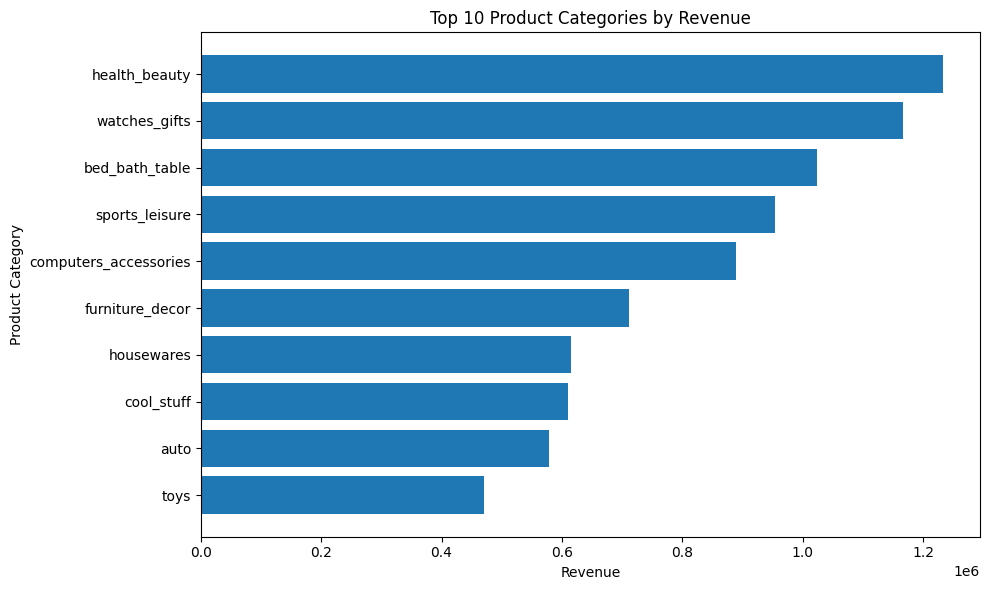

In [17]:
# Top 10 product categories by revenue

top_revenue_categories = (
    category_summary
    .nlargest(10, "revenue")
    .sort_values("revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_revenue_categories["category_name"],
    top_revenue_categories["revenue"]
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

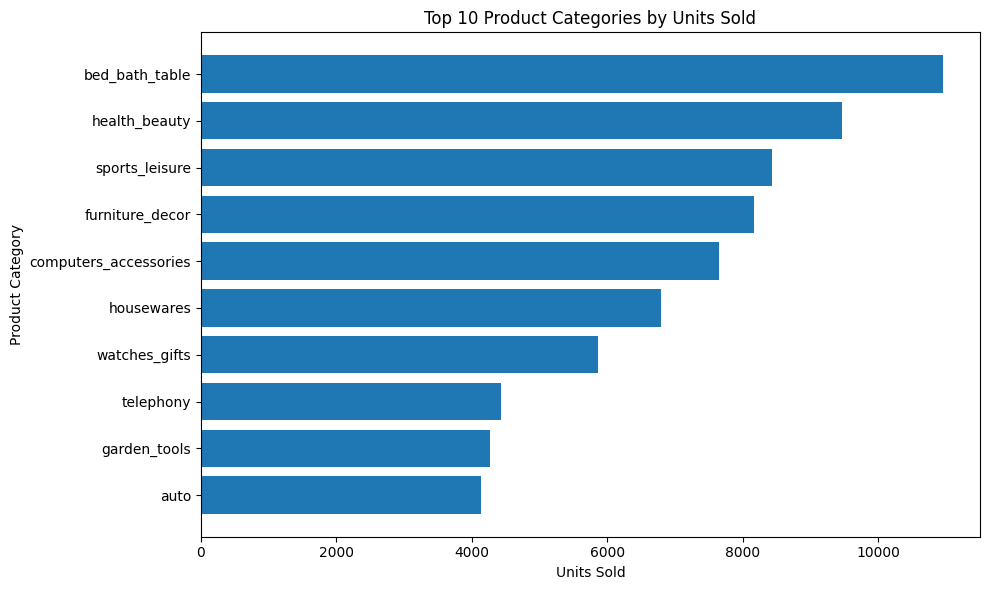

In [18]:
# Top 10 product categories by sales volume

top_volume_categories = (
    category_summary
    .nlargest(10, "units_sold")
    .sort_values("units_sold")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_volume_categories["category_name"],
    top_volume_categories["units_sold"]
)

plt.title("Top 10 Product Categories by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

### Finding

Category performance differs substantially depending on whether it is
measured by revenue or sales volume.

`health_beauty` generated the highest revenue, while `bed_bath_table`
recorded the highest number of units sold. `watches_gifts` also generated
strong revenue despite lower sales volume because of its relatively higher
average item price.

This shows that product performance should be evaluated using both sales
volume and revenue rather than relying on a single metric.

## 7. Geographic Analysis

### Revenue Performance by Customer State

This section examines how revenue, order volume, and customer activity
vary across customer states.

In [19]:
# Aggregate sales performance by customer state

state_summary = (
    sales_df
    .groupby("customer_state")
    .agg(
        customers=("customer_unique_id", "nunique"),
        orders=("order_id", "nunique"),
        revenue=("price", "sum")
    )
    .reset_index()
)

state_summary["aov"] = (
    state_summary["revenue"] / state_summary["orders"]
)

state_summary = state_summary.sort_values(
    "revenue",
    ascending=False
)

state_summary.head(10)

,customer_state,customers,orders,revenue,aov
25,SP,39156,40501,5067633.16,125.123655
18,RJ,11917,12350,1759651.13,142.481873
10,MG,11001,11354,1552481.83,136.734352
22,RS,5168,5345,728897.47,136.369966
17,PR,4769,4923,666063.51,135.296264
23,SC,3449,3546,507012.13,142.981424
4,BA,3158,3256,493584.14,151.592181
6,DF,2019,2080,296498.41,142.547312
8,GO,1895,1957,282836.70,144.525652
7,ES,1928,1995,268643.45,134.658371


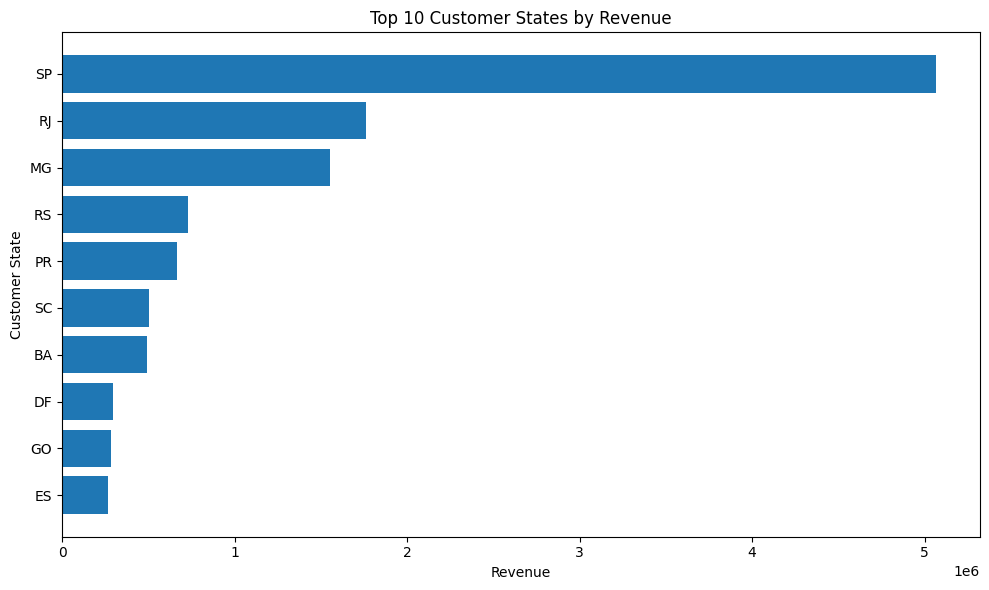

In [20]:
# Top 10 customer states by revenue

top_states = (
    state_summary
    .nlargest(10, "revenue")
    .sort_values("revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_states["customer_state"],
    top_states["revenue"]
)

plt.title("Top 10 Customer States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer State")

plt.tight_layout()
plt.show()

### Finding

Revenue is geographically concentrated in a small number of major markets.

São Paulo (`SP`) is the largest market by a wide margin, generating the
highest revenue, order volume, and customer count. Rio de Janeiro (`RJ`)
and Minas Gerais (`MG`) follow as the next largest markets.

However, market size and average order value are not necessarily aligned.
Some smaller states show higher average order values despite contributing
much less total revenue.

## 8. Delivery and Customer Satisfaction

### Delivery Reliability vs Review Score

This section examines whether customer satisfaction differs between
orders delivered on time and orders delivered after the estimated
delivery date.

In [22]:
operations_query = """
WITH ranked_reviews AS (
    SELECT
        order_id,
        review_score,
        ROW_NUMBER() OVER (
            PARTITION BY order_id
            ORDER BY
                review_answer_timestamp DESC,
                review_creation_date DESC,
                review_id DESC
        ) AS rn
    FROM dbo.reviews
)

SELECT
    o.order_id,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    r.review_score

FROM dbo.orders AS o

LEFT JOIN ranked_reviews AS r
    ON o.order_id = r.order_id
    AND r.rn = 1

WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL;
"""

operations_df = pd.read_sql(operations_query, conn)

operations_df.shape

C:\Users\pc\AppData\Local\Temp\ipykernel_1536\594633693.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  operations_df = pd.read_sql(operations_query, conn)


(96470, 5)

In [23]:
# Classify orders based on delivery reliability

operations_df["delivery_status"] = np.where(
    operations_df["order_delivered_customer_date"]
    <= operations_df["order_estimated_delivery_date"],
    "On Time",
    "Late"
)

# Keep only orders with an available review score
reviewed_operations = operations_df.dropna(
    subset=["review_score"]
).copy()

delivery_review_summary = (
    reviewed_operations
    .groupby("delivery_status")
    .agg(
        reviewed_orders=("order_id", "count"),
        avg_review_score=("review_score", "mean"),
        positive_review_rate_pct=(
            "review_score",
            lambda x: (x >= 4).mean() * 100
        )
    )
    .reset_index()
)

delivery_review_summary

,delivery_status,reviewed_orders,avg_review_score,positive_review_rate_pct
0,Late,7661,2.565070,34.551625
1,On Time,88163,4.294114,82.788698


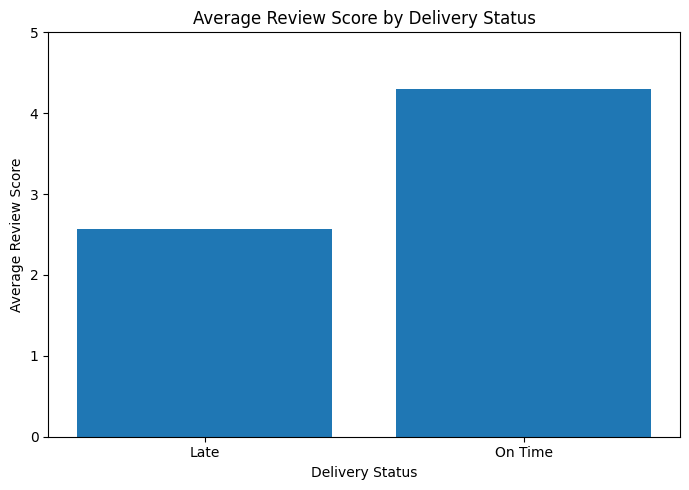

In [24]:
# Compare customer satisfaction by delivery status

plt.figure(figsize=(7, 5))

plt.bar(
    delivery_review_summary["delivery_status"],
    delivery_review_summary["avg_review_score"]
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

### Finding

Delivery reliability is strongly associated with customer satisfaction.

Orders delivered on time received an average review score of approximately
4.29, compared with only 2.57 for late deliveries.

The positive review rate was also substantially higher for on-time orders
(82.79%) than for late orders (34.55%).

This suggests that delivery reliability is an important customer-experience
factor. However, the relationship should be interpreted as an association
rather than proof that late delivery alone causes lower review scores.

## 9. Final Key Findings

The exploratory analysis highlights several important patterns across sales,
customers, products, geography, and delivery performance.

### Sales Performance

- Revenue increased substantially throughout 2017 and reached its highest
  monthly level in November 2017 at approximately 987.8K.
- Revenue growth was driven primarily by increasing order volume rather than
  a persistent increase in average order value.
- Average order value fluctuated across months but did not show the same
  sustained growth pattern as order volume.

### Customer Behavior

- Approximately 97% of customers placed only one delivered order.
- Repeat customers represented only about 3% of the customer base.
- Despite their small share, repeat customers generated substantially more
  revenue per customer than one-time buyers.
- This suggests that customer retention deserves deeper investigation.

### Product Performance

- `health_beauty` generated the highest category revenue.
- `bed_bath_table` recorded the highest sales volume.
- `watches_gifts` achieved strong revenue despite lower sales volume because
  of its relatively higher item prices.
- Category performance should therefore be evaluated using both revenue and
  sales volume.

### Geographic Performance

- São Paulo (`SP`) was the largest market by revenue, order volume, and
  customer count.
- Rio de Janeiro (`RJ`) and Minas Gerais (`MG`) were also major markets.
- Some smaller states showed relatively high average order values despite
  contributing much less total revenue.

### Delivery and Customer Satisfaction

- On-time deliveries received an average review score of approximately 4.29,
  compared with 2.57 for late deliveries.
- The positive review rate was approximately 82.79% for on-time deliveries
  and 34.55% for late deliveries.
- Delivery reliability is strongly associated with customer satisfaction,
  although this relationship should not be interpreted as proof of causation.

### Next Step

The high proportion of one-time customers suggests that retention is an
important area for deeper analysis.

The next notebook will therefore focus on cohort-based customer retention
analysis.